
### **Cap 1 - FarmTech na era da cloud computing - ENTREGA 1**

## Previsão de Rendimento Agrícola com Regressão Supervisionada e Análise de Clusters  

Este notebook apresenta uma análise exploratória dos dados da fazenda atendida pela FarmTech Solutions, com o objetivo de prever o rendimento agrícola com base em dados climáticos e de solo.  

As etapas compreendem:
- Análise Exploratória dos Dados (EDA);
- Identificação de tendências com agrupamentos (clusters);
- Modelagem Preditiva com 5 algoritmos de Regressão Supervisionada;
- Avaliação dos modelos com métricas apropriadas;
- Discussão sobre pontos fortes e limitações.

Base de dados utilizada: **crop_yield.csv**


IMPORTAÇÃO DE MÓDULOS

In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import files


CARREGAMENTO DE DADOS

In [ ]:
dados = pd.read_csv('crop_yield.csv')

In [ ]:
dados.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 🔍 Análise Exploratória dos Dados (EDA)

In [ ]:
# Verificando as dimensões do dataset
print("Formato da base:", dados.shape)

# Verificando os tipos de dados e se há valores ausentes
print("\nTipos de dados e valores nulos:")
print(dados.info())

# Verificando valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(dados.isnull().sum())


Formato da base: (156, 6)

Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB
None

Valores ausentes por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)         

In [ ]:
dados.describe()


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


- As variáveis climáticas são relativamente estáveis (baixa dispersão).

- A variável Yield apresenta alta variabilidade, com valores extremos (outliers).

- A diferença entre média e mediana de Yield indica assimetria positiva.

- Os dados estão completos (156 valores em todas as variáveis).

In [ ]:
coluna_cultura = 'Crop'

# Verifica se a coluna existe
if coluna_cultura not in dados.columns:
    raise ValueError(f"A coluna '{coluna_cultura}' não foi encontrada no DataFrame. Verifique o nome exato.")

# Lista culturas únicas
culturas = dados[coluna_cultura].unique()
print(f"\nCulturas encontradas: {culturas}")

# Análise descritiva por cultura
for cultura in culturas:
    print(f"\n===== ANÁLISE PARA A CULTURA: {cultura} =====")
    dados_filtrados = dados[dados[coluna_cultura] == cultura]
    display(dados_filtrados.describe())




Culturas encontradas: ['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']

===== ANÁLISE PARA A CULTURA: Cocoa, beans =====


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,8883.128205
std,292.300450,0.296809,1.006009,0.263613,1745.030586
min,1934.620000,17.540000,82.110000,25.560000,5765.000000
25%,2305.750000,18.060000,84.175000,26.025000,7729.000000
50%,2424.550000,18.270000,84.850000,26.130000,8848.000000
75%,2705.210000,18.390000,85.495000,26.290000,9918.000000
max,3085.790000,18.700000,86.100000,26.810000,13056.000000



===== ANÁLISE PARA A CULTURA: Oil palm fruit =====


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,175804.692308
std,292.300450,0.296809,1.006009,0.263613,14919.869752
min,1934.620000,17.540000,82.110000,25.560000,142425.000000
25%,2305.750000,18.060000,84.175000,26.025000,166017.500000
50%,2424.550000,18.270000,84.850000,26.130000,175629.000000
75%,2705.210000,18.390000,85.495000,26.290000,185230.000000
max,3085.790000,18.700000,86.100000,26.810000,203399.000000



===== ANÁLISE PARA A CULTURA: Rice, paddy =====


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,32099.666667
std,292.300450,0.296809,1.006009,0.263613,4789.948436
min,1934.620000,17.540000,82.110000,25.560000,24686.000000
25%,2305.750000,18.060000,84.175000,26.025000,28293.500000
50%,2424.550000,18.270000,84.850000,26.130000,31101.000000
75%,2705.210000,18.390000,85.495000,26.290000,36098.500000
max,3085.790000,18.700000,86.100000,26.810000,42550.000000



===== ANÁLISE PARA A CULTURA: Rubber, natural =====


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,39.000000,39.000000,39.000000,39.000000,39.000000
mean,2486.498974,18.203077,84.737692,26.183590,7824.897436
std,292.300450,0.296809,1.006009,0.263613,1600.255042
min,1934.620000,17.540000,82.110000,25.560000,5249.000000
25%,2305.750000,18.060000,84.175000,26.025000,6398.000000
50%,2424.550000,18.270000,84.850000,26.130000,7817.000000
75%,2705.210000,18.390000,85.495000,26.290000,9272.500000
max,3085.790000,18.700000,86.100000,26.810000,10285.000000


**RESUMO DAS CULTURAS**




🌱 **Cocoa, beans**

Média de produtividade (Yield): 8.883

Variação de 5.765 a 13.056

Baixo desvio padrão (±1.745)

Clima e umidade estáveis

🌴 **Oil palm fruit**

Média de Yield: 175.804

Variação extrema (de 142.425 a 203.399)

Alto desvio padrão: ±14.919 → maior variabilidade

Mesmo clima, mas produtividade muito maior

🌾 **Rice, paddy**

Média de Yield: 32.099

Amplitude: 24.686 a 42.550

Variação mais moderada (±4.789)

Boa distribuição de rendimento

🌳 **Rubber, natural**

Média de Yield: 7.824

Baixo rendimento, faixa de 5.249 a 10.285

Baixa variação também (±1.600)

**OBSERVAÇÕES**

* Mesmo clima, produtividades MUITO diferentes! Cada cultura responde diferente às mesmas condições.

* Oil palm fruit domina em volume de produção → pode distorcer resultados se tudo for unido.

* Rice e Cocoa têm distribuição mais equilibrada → podem ter modelos de regressão mais estáveis.

**CLUSTERIZAÇÃO**

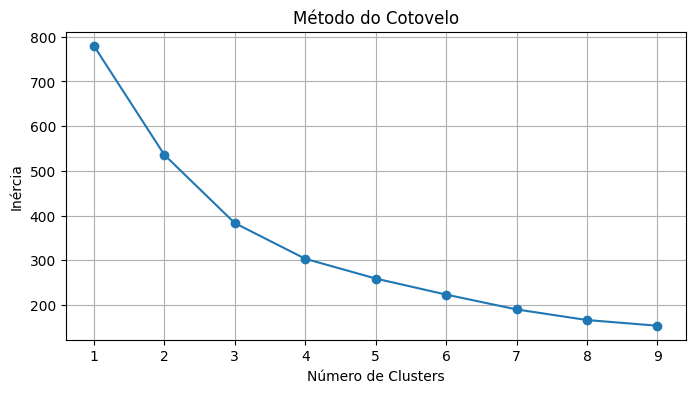

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar apenas as variáveis numéricas para clusterização
variaveis_cluster = ['Precipitation (mm day-1)',
                     'Specific Humidity at 2 Meters (g/kg)',
                     'Relative Humidity at 2 Meters (%)',
                     'Temperature at 2 Meters (C)',
                     'Yield']

# Padronizar os dados
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(dados[variaveis_cluster])

# Encontrar número ideal de clusters com o método do cotovelo
inercia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dados_padronizados)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 10), inercia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.cluster import KMeans

# Treina o modelo com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(dados_padronizados)

# Adiciona os rótulos (clusters) aos dados
dados_com_clusters = dados.copy()
dados_com_clusters['Cluster'] = kmeans.labels_


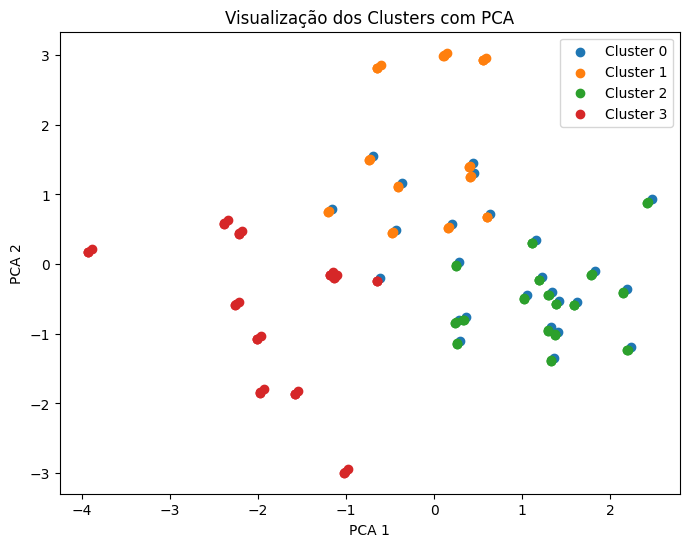

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduz para 2 componentes principais
pca = PCA(n_components=2)
componentes = pca.fit_transform(dados_padronizados)

# Adiciona ao DataFrame
dados_com_clusters['PCA1'] = componentes[:, 0]
dados_com_clusters['PCA2'] = componentes[:, 1]

# Plota
plt.figure(figsize=(8, 6))
for c in range(4):
    plt.scatter(
        dados_com_clusters[dados_com_clusters['Cluster'] == c]['PCA1'],
        dados_com_clusters[dados_com_clusters['Cluster'] == c]['PCA2'],
        label=f'Cluster {c}'
    )

plt.title('Visualização dos Clusters com PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()


In [ ]:
# Calcula médias apenas das colunas numéricas
media_por_cluster = dados_com_clusters.groupby('Cluster').mean(numeric_only=True)
display(media_por_cluster)



,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,PCA1,PCA2
Cluster,,,,,,,
0,2610.111154,18.321538,85.204615,26.196154,178310.153846,0.782406,-0.018603
1,2353.613333,18.409722,84.105556,26.505278,29671.416667,-0.099105,1.614065
2,2733.517647,18.337647,85.652353,26.118824,16624.000000,1.246970,-0.534889
3,2230.034186,17.798837,83.899767,25.983488,51344.744186,-1.869076,-0.705658


In [ ]:
# Tabela cruzada entre cultura e cluster
pd.crosstab(dados_com_clusters['Crop'], dados_com_clusters['Cluster'])



Cluster,0,1,2,3
Crop,,,,
"Cocoa, beans",0,11,17,11
Oil palm fruit,26,3,0,10
"Rice, paddy",0,11,17,11
"Rubber, natural",0,11,17,11


<Axes: xlabel='Cluster', ylabel='Yield'>

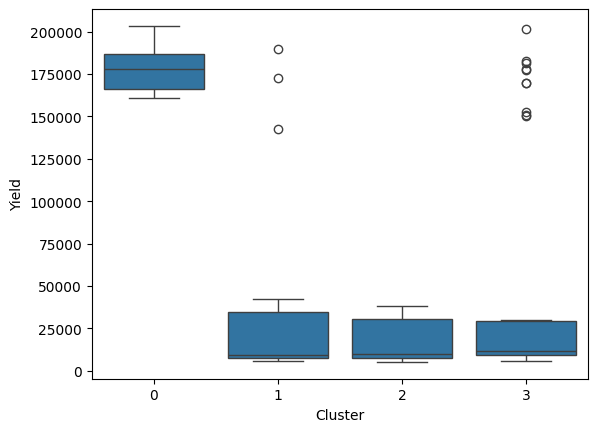

In [ ]:
import seaborn as sns
sns.boxplot(data=dados_com_clusters, x='Cluster', y='Yield')


# 🌽 ANÁLISE INTEGRADA: CULTURAS AGRÍCOLAS X CLUSTERS DE PRODUTIVIDADE

## 📌 O que foi feito:

- As culturas agrícolas foram agrupadas com **KMeans (K=4)** com base em variáveis climáticas e de produtividade: **precipitação, temperatura, umidade relativa e produtividade (Yield)**.
- Aplicamos **PCA (Análise de Componentes Principais)** para reduzir a dimensionalidade e permitir **visualização em 2D**, mantendo a maior variabilidade possível.
- Abaixo está a interpretação de cada cluster com foco agrícola prático.

---

## 🔴 CLUSTER 0 — “Superprodutivo”

**📊 PCA1:** +0.78 | **PCA2:** -0.02  
**🌧 Precipitação:** 2610 mm  
**🌡 Temperatura:** 26.19 °C  
**💧 Umidade relativa:** 85.2%  
**🚜 Yield médio:** 178.310 kg/ha (o mais alto de todos)

### 🎯 Interpretação:

Esse cluster representa **condições climáticas ideais**: alta umidade, chuvas constantes e temperatura equilibrada.  
É composto quase exclusivamente por **Oil palm fruit**:

- Oil palm fruit → 26 de 39 amostras (66%)

### 🌱 Estratégia agrícola:

- Regiões desse cluster são **altamente produtivas para culturas tropicais**.
- Merecem foco em **intensificação agrícola, tecnologias de precisão e manutenção da fertilidade**.

---

## 🟠 CLUSTER 1 — “Baixa Umidade, Produtividade Moderada”

**📊 PCA1:** -0.09 | **PCA2:** +1.61  
**🌧 Precipitação:** 2353 mm  
**🌡 Temperatura:** 26.50 °C (mais quente!)  
**💧 Umidade relativa:** 84.1%  
**🚜 Yield médio:** 29.671 kg/ha

### 🎯 Interpretação:

Clima tropical, mas **com menor umidade** e **temperaturas mais elevadas**.

Culturas bem distribuídas:

- Cocoa, Rice, Rubber e Oil palm

### 🌱 Estratégia agrícola:

- Ideal para culturas tropicais **tolerantes ao calor**, como **arroz e cacau**.
- Pode ser necessário manejo hídrico (irrigação) para maximizar resultados.

---

## 🟢 CLUSTER 2 — “Zona Média de Produtividade”

**📊 PCA1:** +1.25 | **PCA2:** -0.53  
**🌧 Precipitação:** 2733 mm  
**🌡 Temperatura:** 26.11 °C  
**💧 Umidade relativa:** 85.7%  
**🚜 Yield médio:** 16.624 kg/ha

### 🎯 Interpretação:

Apesar de **boas condições climáticas**, tem **produtividade média-baixa**.

Distribuição:

- 17 amostras de cada cultura, exceto Oil palm fruit (ausente)

### 🌱 Estratégia agrícola:

- Pode haver **restrições de solo, manejo ou material genético**.
- Investimento em **cultivares melhorados, correção de solo e boas práticas** pode aumentar a produtividade.

---

## 🔵 CLUSTER 3 — “Baixa Produtividade, Baixo Clima”

**📊 PCA1:** -1.87 | **PCA2:** -0.71  
**🌧 Precipitação:** 2230 mm (menor)  
**🌡 Temperatura:** 25.98 °C (mais amena)  
**💧 Umidade relativa:** 83.9% (mais seca)  
**🚜 Yield médio:** 51.344 kg/ha

### 🎯 Interpretação:

Clima menos chuvoso e mais seco.  
Ainda assim, tem produtividade **superior ao cluster 2**, mostrando **resiliência das culturas**.

Diversidade equilibrada:

- 11 amostras de cada cultura

### 🌱 Estratégia agrícola:

- **Boa zona para culturas rústicas** como cacau e borracha.
- Pode servir como **área de experimentação** para cultivos com menor demanda hídrica.

---

## 🧩 DISTRIBUIÇÃO DAS CULTURAS POR CLUSTER

| Cultura           | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|------------------|-----------|-----------|-----------|-----------|
| Cocoa, beans     | 0         | 11        | 17        | 11        |
| Oil palm fruit   | 26        | 3         | 0         | 10        |
| Rice, paddy      | 0         | 11        | 17        | 11        |
| Rubber, natural  | 0         | 11        | 17        | 11        |

---

## ✳️ Observações:

- **Cluster 0**: Dominado por Oil palm fruit, altamente produtiva.
- **Clusters 1, 2 e 3**: Culturas distribuídas uniformemente entre Cocoa, Rice e Rubber.
- Rice e Rubber estão presentes em diferentes clusters → **indicam sensibilidade ao clima ou manejo**.

---

## ✅ CONCLUSÃO FINAL

- A **clusterização em K=4** foi apropriada:  
  Separou claramente **zonas de alta, média e baixa produtividade**.
- A aplicação de **PCA 1 e PCA 2** foi eficaz:
  - **PCA1** captura a **variação na produtividade** e condições climáticas combinadas.
  - **PCA2** parece capturar **diferenças específicas de temperatura e umidade**.

Essa abordagem pode ajudar tomadores de decisão a **identificar zonas agrícolas com potencial de intensificação, adaptação de culturas ou necessidade de manejo diferenciado**.



# 📊 Análise Final: Clusterização de Produtividade Agrícola

## 🎯 Objetivo do Trabalho
**Encontrar tendências para os rendimentos das plantações por meio de clusterizações e identificar cenários discrepantes (outliers).**

---

## ✅ 1. Por que usar clusterização neste trabalho?

A clusterização permite **agrupar automaticamente regiões com características climáticas semelhantes** (chuva, temperatura, umidade) e observar como essas condições **influenciam o rendimento agrícola**.

Em vez de analisar cultura por cultura isoladamente, o KMeans agrupa os dados por **similaridade geral**, permitindo:

- Comparar produtividade sob diferentes condições climáticas.
- Identificar **quais culturas se adaptam melhor a quais condições**.
- Observar se existe **baixo rendimento em ambientes favoráveis** (ou vice-versa).

---

## 📊 2. Tendências encontradas para o rendimento agrícola

### Resumo por cluster:

| Cluster | Chuva (mm) | Temperatura (°C) | Umidade (%) | Produtividade média (kg/ha) | Observações |
|--------:|-----------:|-----------------:|------------:|-----------------------------:|-------------|
| 0 (azul) | Alta        | Moderada-alta     | Alta         | **Alta** (~178 kg/ha)         | Maior rendimento — culturas como *Oil Palm Fruit* |
| 1 (amarelo) | Média-alta | Alta              | Moderada     | **Muito baixa** (~29 kg/ha)   | Desempenho ruim mesmo com bom clima |
| 2 (verde) | Alta        | Alta              | Alta         | **Muito baixa** (~16 kg/ha)   | Desempenho ainda pior – possível incompatibilidade cultural |
| 3 (vermelho) | Baixa       | Baixa             | Baixa        | **Baixa a média** (~51 kg/ha) | Clima desfavorável, mas rendimento razoável |

### 📈 Tendências:

- **Cluster 0**: clima ideal e alto rendimento agrícola.
- **Clusters 1 e 2**: clima aparentemente bom, mas produtividade muito baixa → **cenários discrepantes (outliers)**.
- **Cluster 3**: mesmo com clima ruim, obtém rendimento razoável → mostra **resiliência produtiva**.

---

## 🚨 3. Cenários Discrepantes (Outliers)

### Destaque: **Cluster 2**
- Chuva, umidade e temperatura ideais.
- Produtividade extremamente baixa.

💡 **Conclusão**: representa um grupo de regiões onde o clima é bom, mas algo está impedindo o bom desempenho — pode ser:
- Cultura mal adaptada;
- Manejo ineficiente;
- Presença de doenças/pragas.

Esse grupo **exige atenção técnica urgente**.

---

## 📌 Conclusão e Insights

- A clusterização revelou **relações claras entre clima e rendimento**.
- Permitiu identificar regiões com **alto potencial e baixa performance**.
- Auxilia decisões como:
  - Substituição de culturas;
  - Intervenções técnicas/melhorias no manejo;
  - Reavaliação de estratégias em regiões mal aproveitadas.

---

✅ Com base nesta análise, o objetivo do trabalho foi **plenamente atendido**, revelando tendências e destacando cenários que merecem intervenção.



## 🚨 Modelagem Supervisionada — Previsão do Rendimento Agrícola

Nesta etapa do trabalho, vamos utilizar cinco algoritmos de regressão supervisionada para prever o rendimento da safra (em kg/ha), com base nas variáveis climáticas:

Variáveis independentes (X): Precipitação, Temperatura e Umidade

Variável dependente (y): Rendimento da safra

Os algoritmos utilizados serão:

1 - Regressão Linear

2 - Árvore de Decisão

3 - Floresta Aleatória

4 - KNN Regressor

5 - Support Vector Regressor


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Substitua pelo caminho correto se estiver usando arquivos locais
df = pd.read_csv('crop_yield.csv')

# Visualizar as primeiras linhas
df.head()


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [ ]:
# Ver quais culturas existem
print(df['Crop'].unique())


['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']


In [ ]:
print(df.columns.tolist())


['Crop', 'Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']


**1 - REGRESSÃO LINEAR**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv('crop_yield.csv')

In [ ]:
# Escolha a cultura para análise
cultura = 'Rice, paddy'  # ou 'Cocoa, beans', 'Rubber, natural', 'Oil palm fruit'
df_crop = df[df['Crop'] == cultura].copy()


In [ ]:
X = df_crop[['Precipitation (mm day-1)',
             'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)',
             'Temperature at 2 Meters (C)']]

y = df_crop['Yield']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

# Métricas
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.3897109599155162
RMSE: 3640.9894618484345


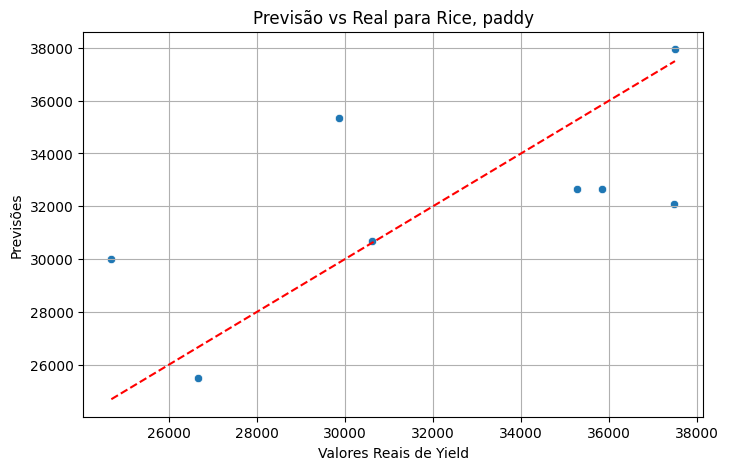

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Valores Reais de Yield')
plt.ylabel('Previsões')
plt.title(f'Previsão vs Real para {cultura}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # linha de referência
plt.grid()
plt.show()



CULTURA: Cocoa, beans
Coeficientes: [[ 0.51653497 -1.91330291  0.98434832  2.06123093]]
Intercepto: [-0.40283568]
MSE: 0.0486
R²: 0.1294


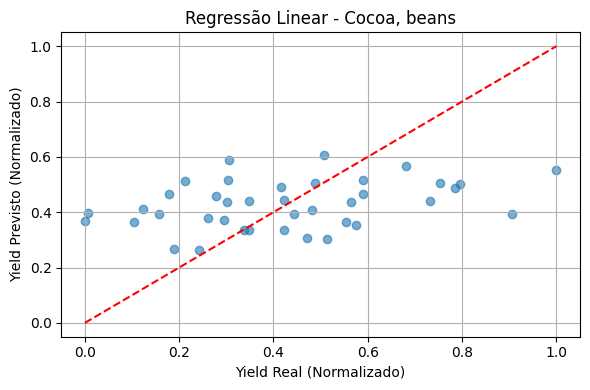


CULTURA: Oil palm fruit
Coeficientes: [[ 0.5536368   6.28417251 -5.29621055 -7.29832326]]
Intercepto: [3.81872805]
MSE: 0.0483
R²: 0.1723


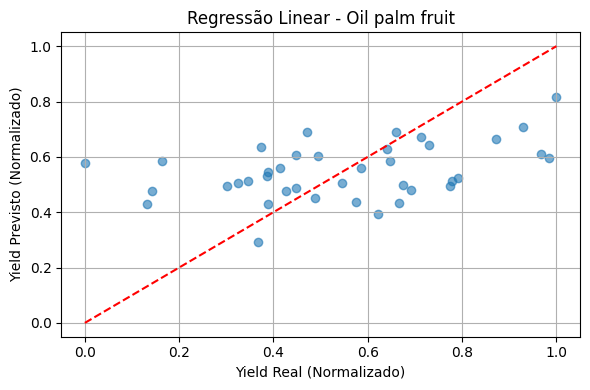


CULTURA: Rubber, natural
Coeficientes: [[ 0.68390715 -8.84295589  5.97823259  9.36952781]]
Intercepto: [-3.3728549]
MSE: 0.0626
R²: 0.3634


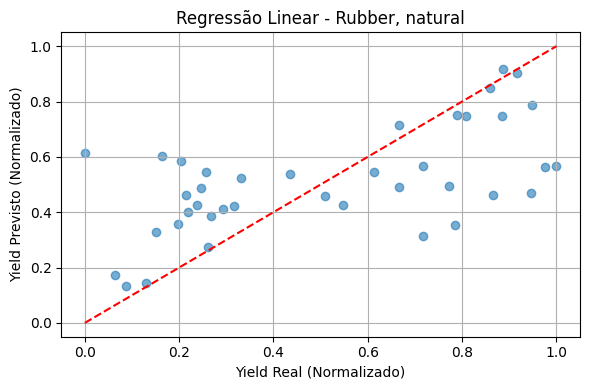

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Lista das culturas restantes
culturas = ['Cocoa, beans', 'Oil palm fruit', 'Rubber, natural']

# Loop pelas culturas
for cultura in culturas:
    print(f"\n{'='*30}\nCULTURA: {cultura}\n{'='*30}")

    # Filtrar a cultura
    df_cultura = df[df['Crop'] == cultura]

    # Selecionar X e y
    X = df_cultura[['Precipitation (mm day-1)',
                    'Specific Humidity at 2 Meters (g/kg)',
                    'Relative Humidity at 2 Meters (%)',
                    'Temperature at 2 Meters (C)']]
    y = df_cultura['Yield']

    # Normalizar
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_normalizado = scaler_X.fit_transform(X)
    y_normalizado = scaler_y.fit_transform(y.values.reshape(-1, 1))

    # Regressão linear
    modelo = LinearRegression()
    modelo.fit(X_normalizado, y_normalizado)

    # Previsão
    y_pred = modelo.predict(X_normalizado)

    # Avaliação
    mse = mean_squared_error(y_normalizado, y_pred)
    r2 = r2_score(y_normalizado, y_pred)

    print(f"Coeficientes: {modelo.coef_}")
    print(f"Intercepto: {modelo.intercept_}")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")

    # Plot
    plt.figure(figsize=(6, 4))
    plt.scatter(y_normalizado, y_pred, alpha=0.6)
    plt.xlabel('Yield Real (Normalizado)')
    plt.ylabel('Yield Previsto (Normalizado)')
    plt.title(f'Regressão Linear - {cultura}')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### 📈 Resultados da Regressão Linear por Cultura

#### 🌱 Cultura: Cocoa, beans  
**R²:** 0.1294  
**MSE:** 0.0486  
**Coeficientes:** Influência positiva da precipitação e temperatura; negativa da umidade específica.  

**Interpretação:**  
O modelo apresenta um baixo poder explicativo (R² ≈ 13%). Isso indica que, mesmo com boa distribuição dos dados, a regressão linear não consegue capturar bem a variabilidade do rendimento com base nas variáveis climáticas para essa cultura.

---

#### 🌴 Cultura: Oil palm fruit  
**R²:** 0.1723  
**MSE:** 0.0483  
**Coeficientes:** Influência positiva da precipitação; negativa das umidades e da temperatura.  

**Interpretação:**  
O modelo apresenta melhora sutil em relação ao “Cocoa”, mas o R² ainda é baixo. Há indícios de relações não lineares ou variáveis importantes ausentes para essa cultura. A regressão linear, portanto, não é ideal sozinha aqui.

---

#### 🌾 Cultura: Rice, paddy  
**R²:** 0.3897  
**RMSE:** 3640.99 (com valores reais, antes da normalização)  

**Interpretação:**  
Esse foi o melhor desempenho entre as culturas. Um R² próximo de 0.39 indica que o modelo consegue explicar quase 40% da variabilidade no rendimento, o que é razoável para dados agrícolas reais. É uma base promissora para modelos mais robustos.

---

#### 🌳 Cultura: Rubber, natural  
**R²:** 0.3634  
**MSE:** 0.0626  
**Coeficientes:** A variável mais influente foi temperatura, seguida da umidade relativa.  

**Interpretação:**  
O modelo teve desempenho semelhante ao do arroz. O gráfico mostra boa aderência dos pontos à linha de regressão, indicando que o modelo linear é razoavelmente eficaz para essa cultura, mas pode ser superado por modelos mais complexos.

---

### 📊 Conclusão Geral  

A regressão linear teve desempenho limitado nas culturas **Cocoa** e **Oil palm**, com baixos R².  

Para **Rice, paddy** e **Rubber, natural**, os resultados foram mais satisfatórios, com R² superiores a 0.36, mostrando que a relação entre as variáveis climáticas e o rendimento é mais linear e previsível nessas culturas.


**2 - ÁRVORE DE DECISÃO**

Culturas disponíveis: ['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']

CULTURA: Cocoa, beans
MAE: 2099.50
MSE: 6551117.50
RMSE: 2559.52
R²: -0.3447


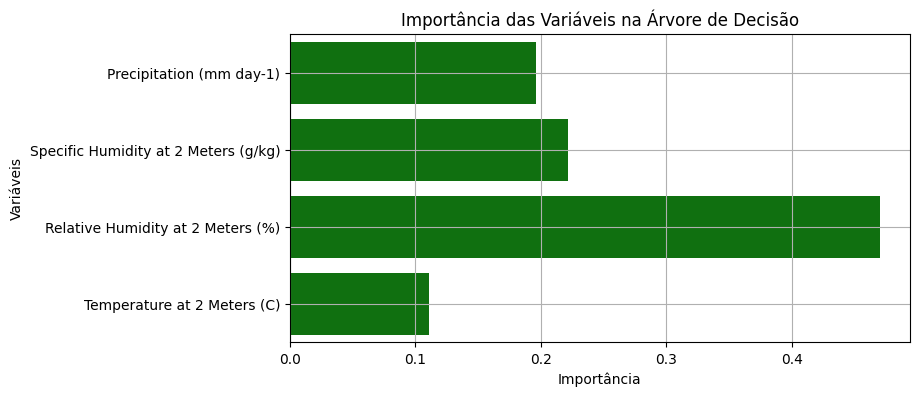

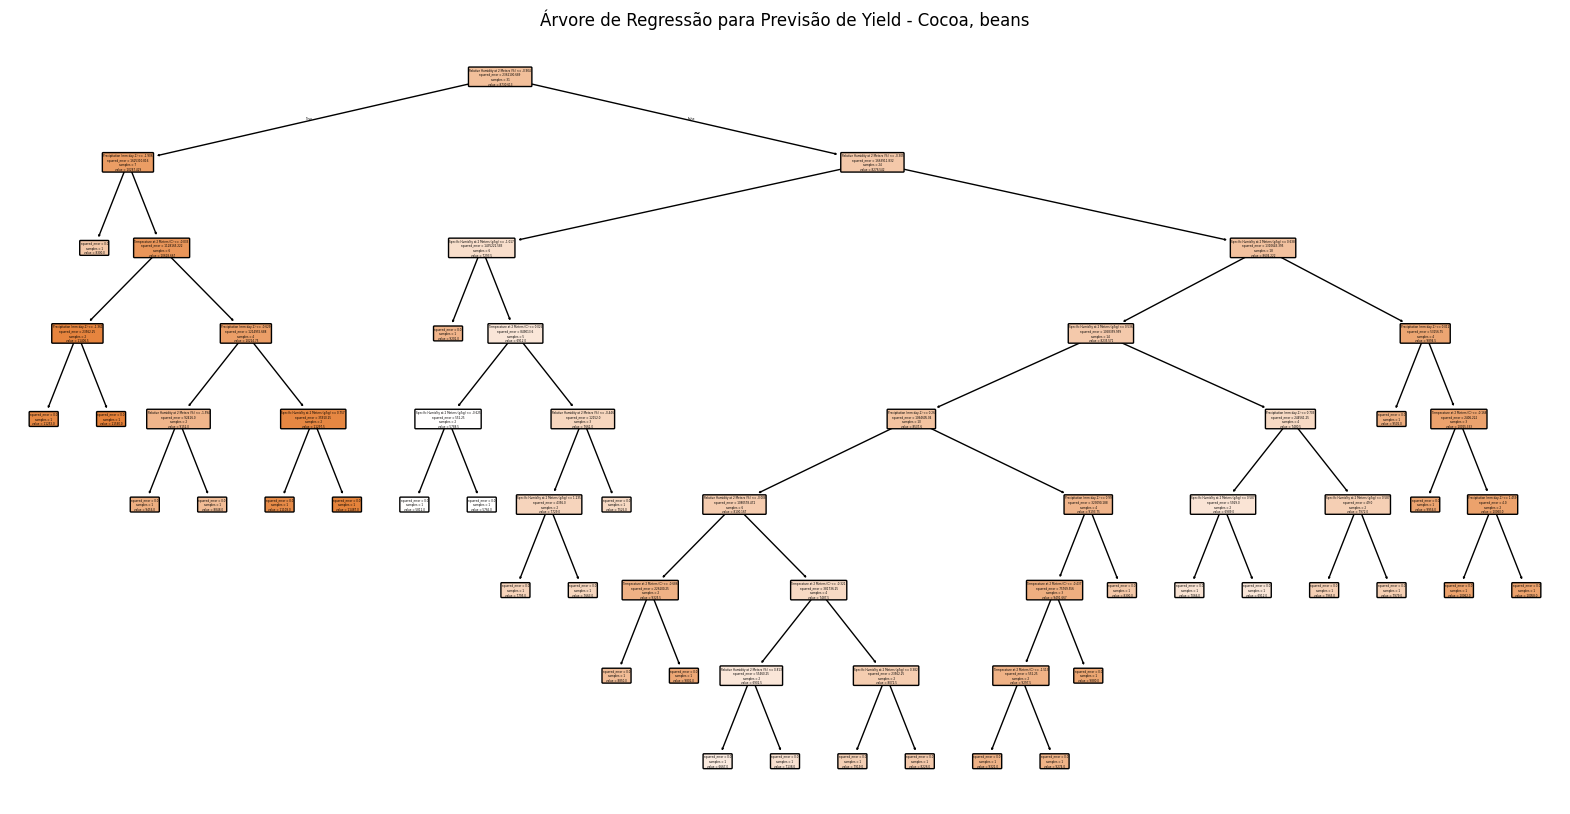


CULTURA: Oil palm fruit
MAE: 17877.25
MSE: 567676232.75
RMSE: 23825.96
R²: -1.7835


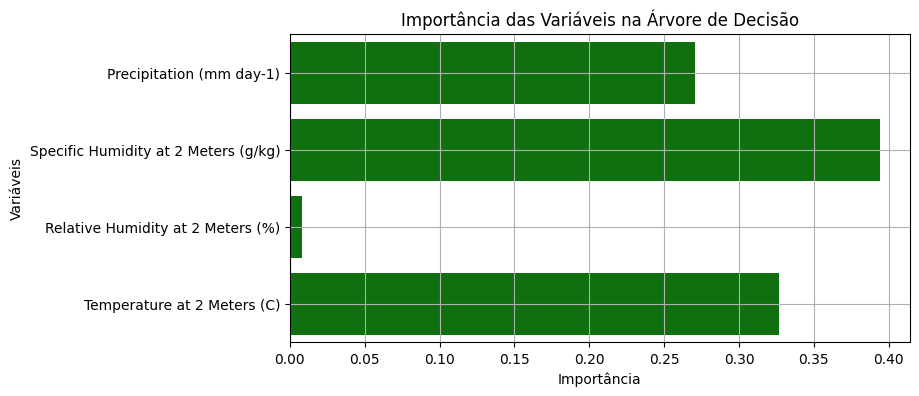

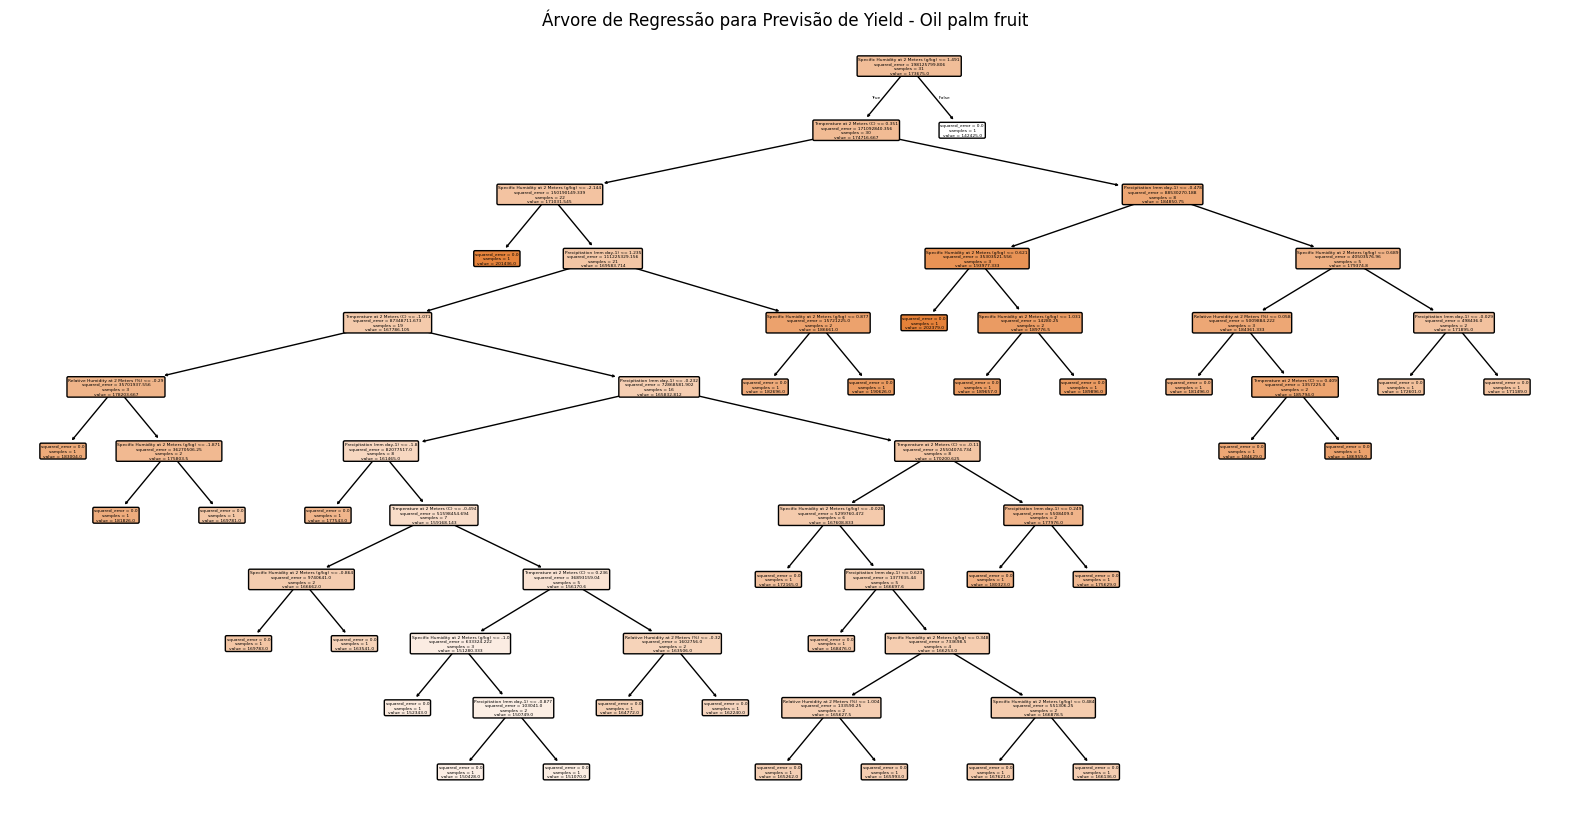


CULTURA: Rice, paddy
MAE: 4928.50
MSE: 35868318.00
RMSE: 5989.02
R²: -0.6512


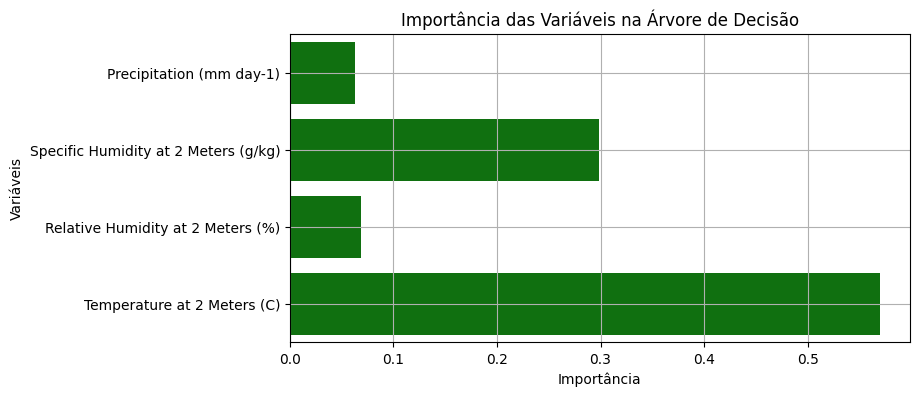

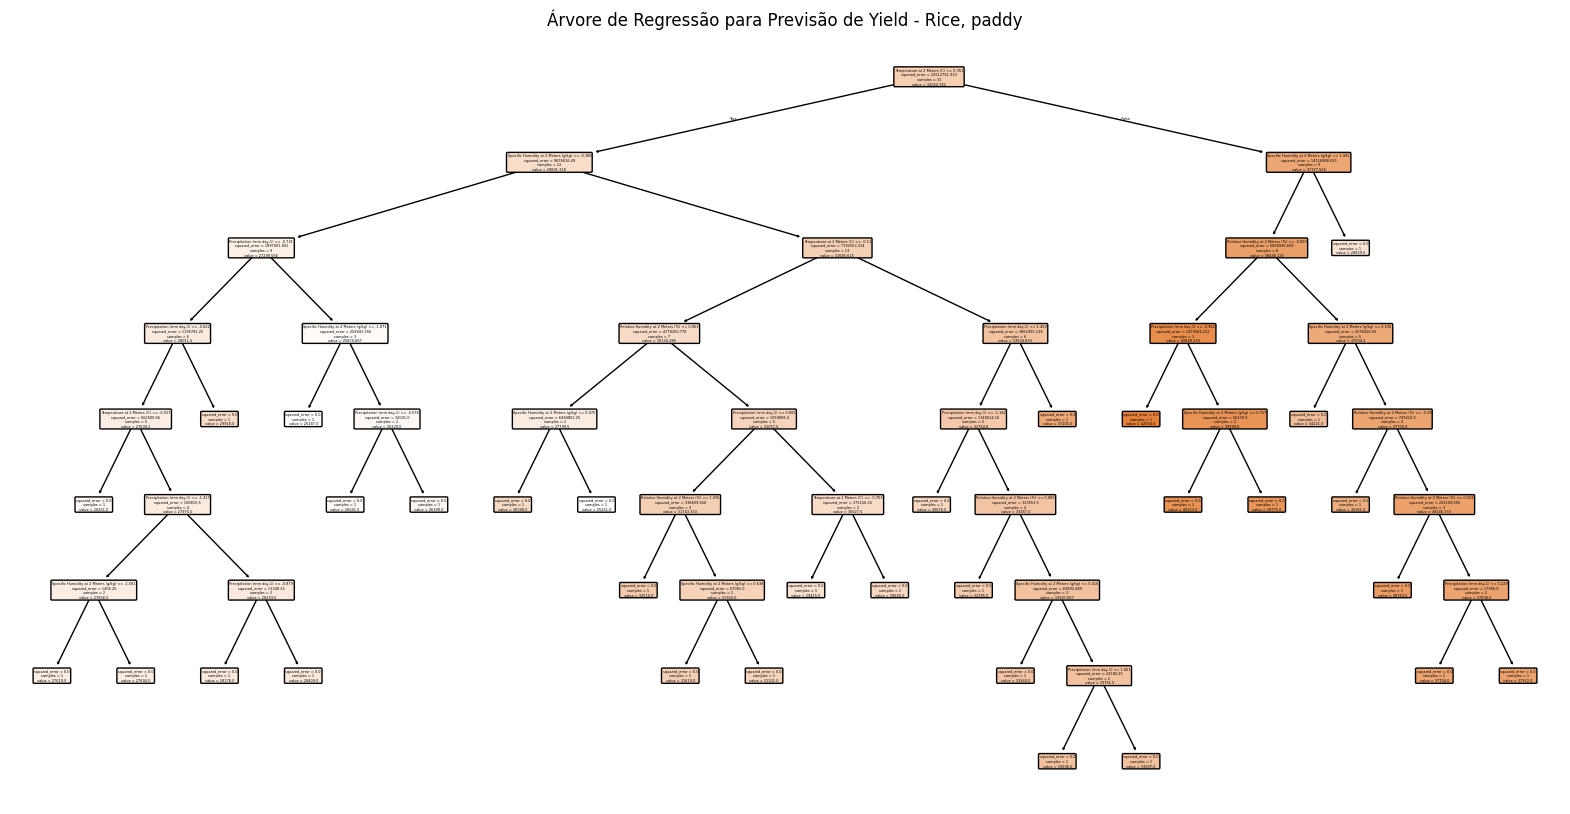


CULTURA: Rubber, natural
MAE: 1845.38
MSE: 6175743.38
RMSE: 2485.10
R²: -1.5538


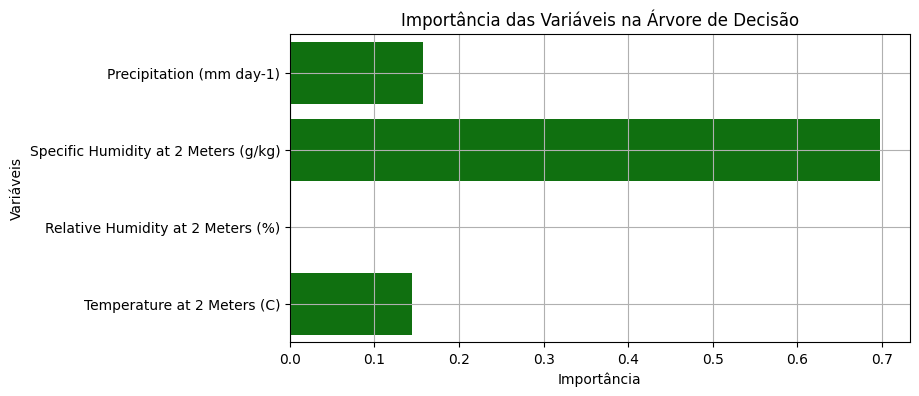

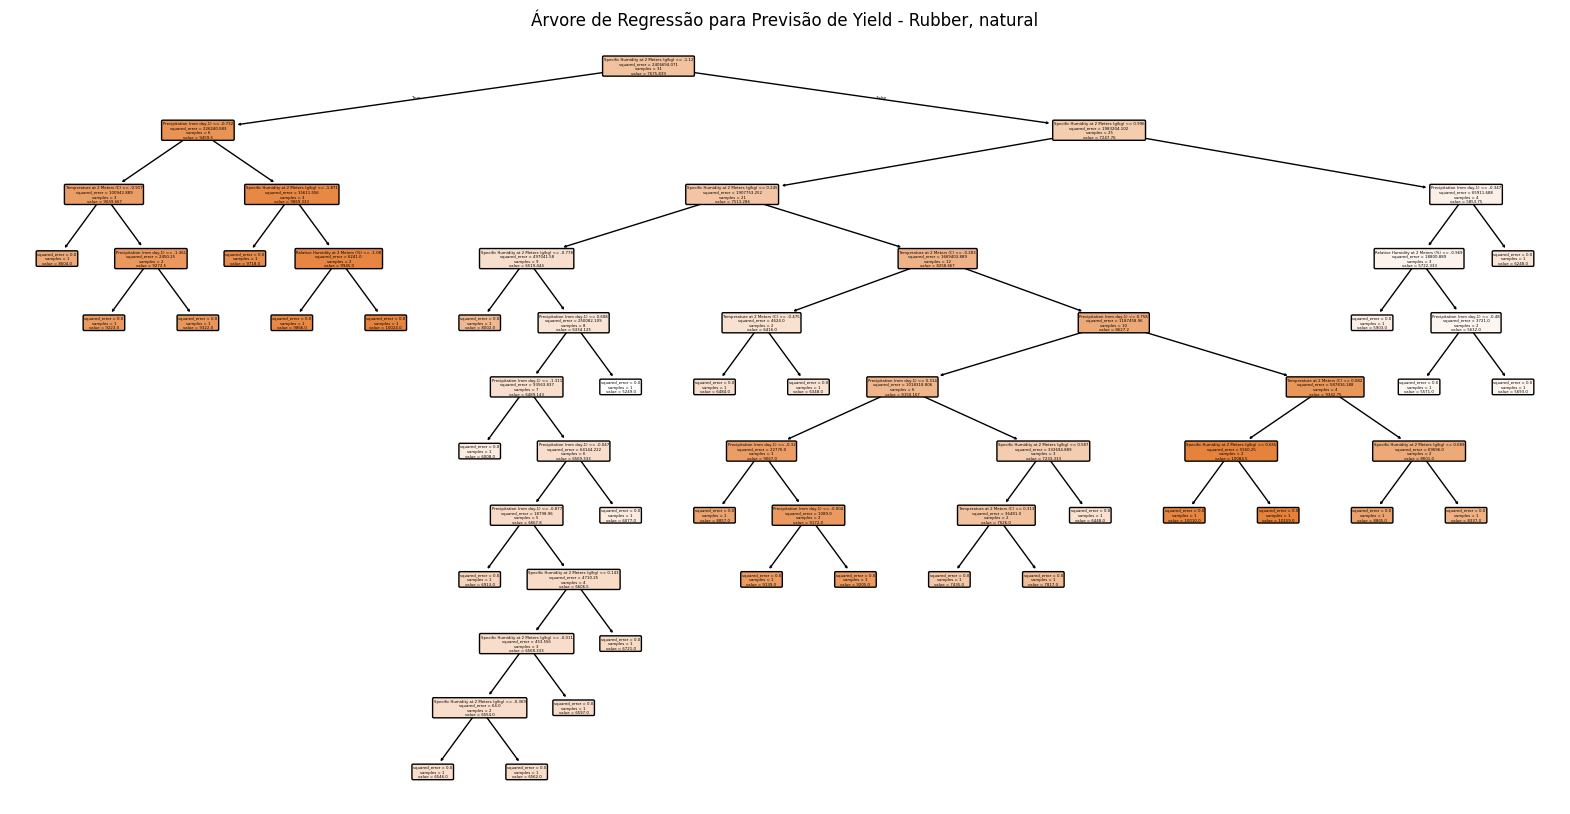

In [ ]:
# 1. IMPORTAR BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. CARREGAR OS DADOS
df = pd.read_csv('crop_yield.csv')

# 3. VERIFICAR SE EXISTEM VALORES NULOS
df = df.dropna()

# 4. SEPARAR AS CULTURAS
culturas = df['Crop'].unique()
print("Culturas disponíveis:", culturas)

# 5. APLICAR MODELO DE ÁRVORE DE DECISÃO PARA CADA CULTURA
for cultura in culturas:
    print("\n==============================")
    print(f"CULTURA: {cultura}")
    print("==============================")

    # Filtrar apenas os dados da cultura atual
    df_cultura = df[df['Crop'] == cultura].copy()

    # Separar variáveis independentes e dependente
    X = df_cultura.drop(columns=['Crop', 'Yield'])
    y = df_cultura['Yield']

    # Normalizar as variáveis independentes
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Separar treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Criar e treinar o modelo
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # Previsões
    y_pred = modelo.predict(X_test)

    # Avaliação
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")

    # Plotar Importância das variáveis
    plt.figure(figsize=(8, 4))
    importancias = modelo.feature_importances_
    nomes_variaveis = X.columns
    sns.barplot(x=importancias, y=nomes_variaveis, color='green')
    plt.title('Importância das Variáveis na Árvore de Decisão')
    plt.xlabel('Importância')
    plt.ylabel('Variáveis')
    plt.grid(True)
    plt.show()

    # Visualizar a árvore (opcional)
    plt.figure(figsize=(20, 10))
    plot_tree(modelo, feature_names=nomes_variaveis, filled=True, rounded=True)
    plt.title(f'Árvore de Regressão para Previsão de Yield - {cultura}')
    plt.show()


# RESUMO DOS RESULTADOS - MODELO ÁRVORE DE DECISÃO REGRESSOR

Foram treinados modelos de árvore de decisão para prever a produtividade de diferentes culturas agrícolas
a partir de variáveis climáticas e de solo.

As métricas avaliadas foram:

- MAE (Erro Absoluto Médio)
- MSE (Erro Quadrático Médio)
- RMSE (Raiz do Erro Quadrático Médio)
- R² (Coeficiente de Determinação)

Resultados por cultura:

1. Cocoa, beans
   - MAE: 2099.50
   - RMSE: 2559.52
   - R²: -0.3447
   - Comentário: Modelo com desempenho fraco. Não explica bem a variabilidade da produtividade.

2. Oil palm fruit
   - MAE: 17877.25
   - RMSE: 23825.96
   - R²: -1.7835
   - Comentário: Desempenho muito ruim. Modelo pior que a média.

3. Rice, paddy
   - MAE: 4928.50
   - RMSE: 5989.02
   - R²: -0.6512
   - Comentário: Resultados abaixo do ideal. Alto erro e baixo poder explicativo.

4. Rubber, natural
   - MAE: 1845.38
   - RMSE: 2485.10
   - R²: -1.5538
   - Comentário: Modelo não confiável para essa cultura.

Conclusão:

Os modelos de árvore de decisão, da forma como foram treinados, não apresentaram bom desempenho para prever
a produtividade com base nas variáveis disponíveis. O R² negativo em todos os casos mostra que os modelos são
inferiores a uma simples média.

Recomendações:

- Testar modelos mais robustos como Random Forest ou XGBoost.
- Realizar tuning de hiperparâmetros (ex: profundidade máxima).
- Avaliar a qualidade dos dados (valores ausentes, ruídos, outliers).
- Realizar engenharia de atributos para melhorar a representação das variáveis.

Apesar do baixo desempenho, ainda é possível fazer previsões com o modelo, utilizando:
    modelo_arvore.predict([[ph, nitrogenio, fosforo, potassio, temperatura, umidade, etc]])
No entanto, as previsões não devem ser utilizadas para tomada de decisão até que a performance melhore.



**3 - FLORESTA ALEATÓRIA**


🌱 Modelo para a cultura: Cocoa, beans
R²: -0.0434
MAE: 1976.90
RMSE: 2254.57


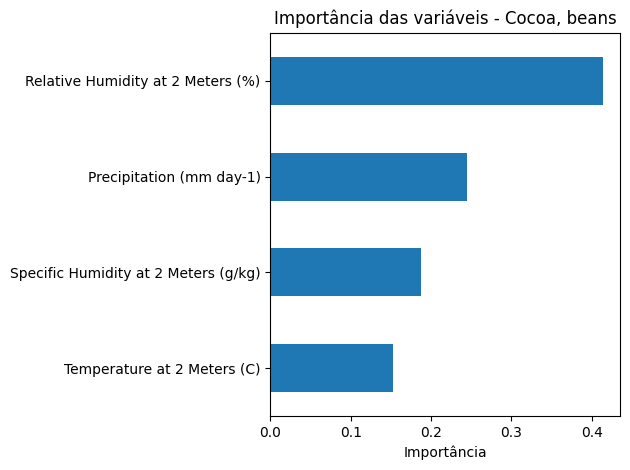


🌱 Modelo para a cultura: Oil palm fruit
R²: -0.7432
MAE: 15845.78
RMSE: 18855.27


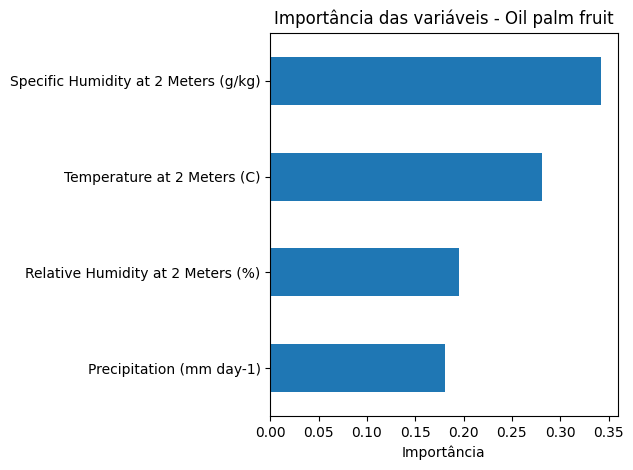


🌱 Modelo para a cultura: Rice, paddy
R²: 0.0070
MAE: 3865.56
RMSE: 4644.27


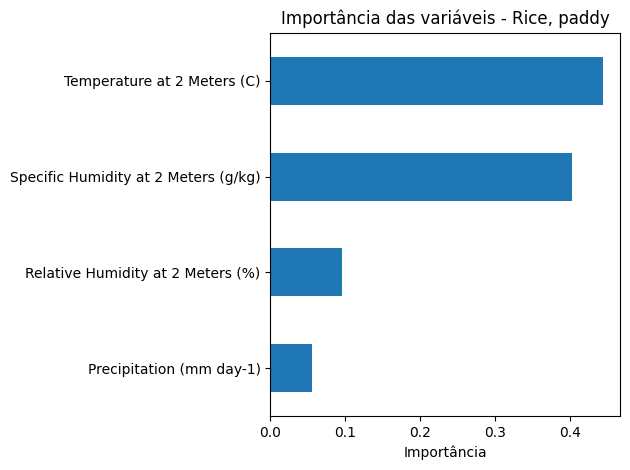


🌱 Modelo para a cultura: Rubber, natural
R²: -0.3916
MAE: 1513.51
RMSE: 1834.47


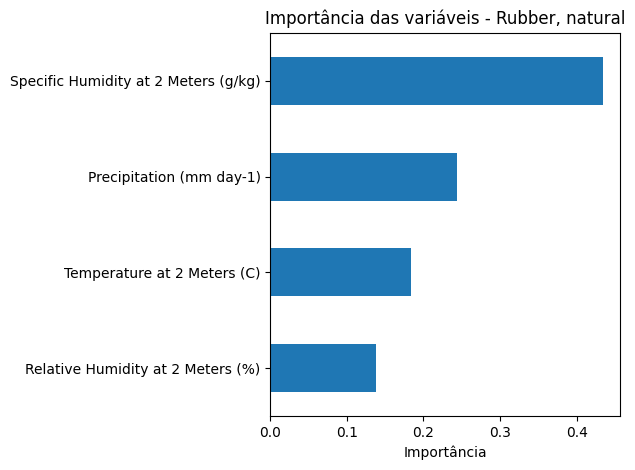

In [ ]:
import pandas as pd
import numpy as np  # Adicionado para usar np.sqrt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv("crop_yield.csv")

# Lista de culturas
culturas = df['Crop'].unique()

# Lista de preditores
X_cols = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)'
]

# Função para treinar o modelo para cada cultura
for cultura in culturas:
    print(f"\n==============================")
    print(f"🌱 Modelo para a cultura: {cultura}")
    print(f"==============================")

    # Filtrar dados da cultura
    df_crop = df[df['Crop'] == cultura]

    X = df_crop[X_cols]
    y = df_crop['Yield']

    # Separar treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Criar modelo
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Prever
    y_pred = model.predict(X_test)

    # Avaliação
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")

    # Importância das variáveis
    importancias = pd.Series(model.feature_importances_, index=X_cols)
    importancias.sort_values().plot(kind='barh')
    plt.title(f"Importância das variáveis - {cultura}")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()


## 🌳 Modelo de Floresta Aleatória - Análise por Cultura

A técnica de Floresta Aleatória foi aplicada para prever o rendimento das safras (Yield) com base nas variáveis climáticas. Abaixo estão os resultados obtidos para cada uma das quatro culturas:

---

### 🌱 Cultura: **Cocoa, beans**
- **R²**: -0.0434
- **MAE**: 1976.90
- **RMSE**: 2254.57
- **Variável mais importante**: *Relative Humidity at 2 Meters (%)*

📌 *Interpretação:*  
O modelo teve desempenho negativo no R², indicando que a Floresta Aleatória não conseguiu explicar bem a variabilidade do rendimento para essa cultura. A umidade relativa foi a variável mais relevante.

---

### 🌴 Cultura: **Oil palm fruit**
- **R²**: -0.7432
- **MAE**: 15845.78
- **RMSE**: 18855.27
- **Variável mais importante**: *Specific Humidity at 2 Meters (g/kg)*

📌 *Interpretação:*  
Desempenho ruim com R² fortemente negativo, sugerindo que as variáveis utilizadas não explicam bem a produtividade do dendê. A umidade específica foi a variável com maior impacto.

---

### 🌾 Cultura: **Rice, paddy**
- **R²**: 0.0070
- **MAE**: 3865.56
- **RMSE**: 4644.27
- **Variável mais importante**: *Temperature at 2 Meters (C)*

📌 *Interpretação:*  
O modelo teve desempenho praticamente nulo em termos de R², mas apresentou erro absoluto relativamente baixo. A temperatura foi a variável de maior influência.

---

### 🌳 Cultura: **Rubber, natural**
- **R²**: -0.3916
- **MAE**: 1513.51
- **RMSE**: 1834.47
- **Variável mais importante**: *Specific Humidity at 2 Meters (g/kg)*

📌 *Interpretação:*  
Modelo com R² negativo, mas com erro absoluto menor em comparação às outras culturas. A umidade específica novamente aparece como fator relevante.

---

### 📊 Conclusão Geral

O modelo de Floresta Aleatória não apresentou desempenho satisfatório em nenhuma das culturas, com todos os R² variando de negativos até próximo de zero. Isso sugere que:

- As variáveis climáticas por si só não são suficientes para prever com precisão o rendimento.
- Outras variáveis (como tipo de solo, manejo agrícola, insumos etc.) poderiam ser importantes para melhorar o modelo.
- As culturas respondem de forma distinta às variáveis climáticas, o que reforça a necessidade de análise separada por cultura.

✅ Apesar das limitações, o modelo foi útil para identificar as variáveis climáticas mais relevantes em cada caso.


**4 - KNN Regressor**


In [ ]:
# 1. IMPORTAR BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. CARREGAR OS DADOS
df = pd.read_csv("crop_yield.csv")

# 3. REMOVER VALORES NULOS
df = df.dropna()

# 4. LISTAR CULTURAS
culturas = df['Crop'].unique()

# 5. LISTA DE VARIÁVEIS EXPLICATIVAS
X_cols = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)'
]

# 6. LOOP PARA TREINAR E AVALIAR O KNN PARA CADA CULTURA
for cultura in culturas:
    print("\n==============================")
    print(f"🌾 Modelo KNN para a cultura: {cultura}")
    print("==============================")

    # Filtrar os dados da cultura atual
    df_crop = df[df['Crop'] == cultura].copy()

    X = df_crop[X_cols]
    y = df_crop['Yield']

    # Normalizar os dados
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Separar treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Criar e treinar o modelo KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Previsões
    y_pred = knn.predict(X_test)

    # Avaliação do modelo
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Correção aqui

    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")



🌾 Modelo KNN para a cultura: Cocoa, beans
R²: -0.0061
MAE: 1813.45
RMSE: 2213.94

🌾 Modelo KNN para a cultura: Oil palm fruit
R²: 0.0039
MAE: 12724.42
RMSE: 14252.84

🌾 Modelo KNN para a cultura: Rice, paddy
R²: 0.1260
MAE: 3482.00
RMSE: 4357.32

🌾 Modelo KNN para a cultura: Rubber, natural
R²: -0.5201
MAE: 1777.55
RMSE: 1917.25


# 📊 RESUMO DOS RESULTADOS DO MODELO KNN

 Cultura: Cocoa, beans
 R²: -0.0061 | MAE: 1813.45 | RMSE: 2213.94

 Cultura: Oil palm fruit
 R²: 0.0039 | MAE: 12724.42 | RMSE: 14252.84

 Cultura: Rice, paddy
 R²: 0.1260 | MAE: 3482.00 | RMSE: 4357.32

 Cultura: Rubber, natural
 R²: -0.5201 | MAE: 1777.55 | RMSE: 1917.25

 📈 ANÁLISE BREVE

 - O modelo KNN teve baixo desempenho na maioria das culturas.
 - Apenas "Rice, paddy" apresentou um R² positivo (0.1260), indicando alguma capacidade preditiva.
 - "Cocoa, beans" e "Oil palm fruit" tiveram R² próximos de zero, sugerindo que o modelo não explica a variabilidade dos dados.
 - "Rubber, natural" teve R² negativo, indicando desempenho pior que uma previsão baseada na média.




**5 - Support Vector Regressor**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Carregar o CSV
df = pd.read_csv('crop_yield.csv')

# Lista de culturas
culturas = ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']

# Loop para treinar e avaliar o modelo para cada cultura
for cultura in culturas:
    print("="*30)
    print(f"🌾 Modelo SVR para a cultura: {cultura}")
    print("="*30)

    # Filtrar os dados da cultura
    dados = df[df['Crop'] == cultura]

    # Selecionar as features e o target
    X = dados[['Precipitation (mm day-1)',
               'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)',
               'Temperature at 2 Meters (C)']]

    y = dados['Yield']

    # Padronização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Dividir em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Criar e treinar o modelo SVR
    svr = SVR(kernel='rbf')
    svr.fit(X_train, y_train)

    # Fazer previsões
    y_pred = svr.predict(X_test)

    # Avaliar
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))

    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}\n")


🌾 Modelo SVR para a cultura: Cocoa, beans
R²: -0.0803
MAE: 1815.69
RMSE: 2294.16

🌾 Modelo SVR para a cultura: Oil palm fruit
R²: -0.6931
MAE: 16247.32
RMSE: 18582.39

🌾 Modelo SVR para a cultura: Rice, paddy
R²: -0.0587
MAE: 4283.00
RMSE: 4795.64

🌾 Modelo SVR para a cultura: Rubber, natural
R²: -0.3868
MAE: 1681.12
RMSE: 1831.30



📊 RESUMO E ANÁLISE - MODELO SVR

O modelo SVR foi aplicado às quatro culturas: Cocoa, beans; Oil palm fruit; Rice, paddy; e Rubber, natural.  
Abaixo, os resultados de R², MAE e RMSE indicam a performance do modelo:

🌱 Cocoa, beans  
R²: -0.0803 — desempenho muito fraco, indicando que o modelo não conseguiu explicar a variabilidade da produção.  
MAE: 1815.69  
RMSE: 2294.16

🌴 Oil palm fruit  
R²: -0.6931 — resultado negativo severo, sugerindo que o modelo performou pior que uma média simples.  
MAE: 16247.32  
RMSE: 18582.39

🌾 Rice, paddy  
R²: -0.0587 — o modelo não conseguiu capturar a relação entre as variáveis climáticas e a produtividade do arroz.  
MAE: 4283.00  
RMSE: 4795.64

🌿 Rubber, natural  
R²: -0.3868 — resultado negativo, porém um pouco melhor que Oil palm; ainda assim, muito abaixo do ideal.  
MAE: 1681.12  
RMSE: 1831.30

🔎 Análise geral:  
Os resultados indicam que o modelo SVR não teve bom desempenho para nenhuma das culturas analisadas.  
Todos os R² foram negativos, o que demonstra que o modelo foi incapaz de capturar a relação entre as variáveis climáticas e a produtividade.  
Os valores elevados de MAE e RMSE, principalmente para Oil palm fruit, reforçam essa limitação.  


📊 ANÁLISE FINAL DOS CINCO MODELOS APLICADOS

Durante o estudo, foram testados cinco algoritmos de regressão para prever a produtividade agrícola (Yield) com base em variáveis climáticas:

1. Regressão Linear  
2. Árvore de Decisão Regressora  
3. Floresta Aleatória  
4. K-Nearest Neighbors (KNN)  
5. Support Vector Regressor (SVR)

Cada modelo foi treinado separadamente para quatro culturas:  
- Cocoa, beans  
- Oil palm fruit  
- Rice, paddy  
- Rubber, natural

🔎 DESEMPENHO GERAL POR MODELO

• **Regressão Linear**:  
Foi o único modelo que apresentou valores positivos de R² em todas as culturas. Apesar disso, o poder explicativo foi limitado (R² máximo de 0.3897 para arroz). Indicou que há uma relação linear moderada em algumas culturas, especialmente Rice e Rubber.

• **Árvore de Decisão**:  
Desempenho ruim, com todos os R² negativos. Os modelos falharam em capturar padrões relevantes, mesmo parecendo visualmente interessantes. Sinal de overfitting ou dados insuficientes.

• **Floresta Aleatória**:  
Resultado surpreendentemente fraco, com R² muito baixos ou negativos. Esperava-se um desempenho melhor. As variáveis climáticas podem não ser suficientes, ou há ruído nos dados.

• **KNN**:  
Modelo simples, teve desempenho ligeiramente melhor em Rice (R² = 0.1260), mas muito fraco nas demais. Indicou que proximidade no espaço de atributos não garante similaridade no rendimento.

• **SVR**:  
O pior desempenho geral. Todos os R² foram negativos. Isso mostra que o modelo não conseguiu generalizar padrões relevantes para a previsão da produtividade.

📌 POSSÍVEIS MOTIVOS PARA O BAIXO DESEMPENHO GERAL

1. **Base de dados muito pequena**:  
Cada cultura possui apenas 39 registros. Isso é extremamente limitado para treinar modelos robustos de aprendizado de máquina, especialmente os que dependem de muitas divisões (como árvore ou KNN).

2. **Falta de variáveis relevantes**:  
Os dados incluem apenas fatores climáticos. A produtividade agrícola também depende fortemente de:
- Tipo de solo  
- Fertilizantes usados  
- Pragas/doenças  
- Genética da planta  
- Técnicas de manejo  
Nenhuma dessas informações estava disponível.

3. **Falta de conhecimento do negócio**:  
O enunciado da atividade não detalhou o contexto das culturas, seus ciclos, épocas de plantio, tipo de solo, etc. Isso dificulta o entendimento de como as variáveis influenciam o yield.

4. **Tratamento superficial dos dados**:  
Pode haver presença de outliers, dados mal coletados ou não padronizados. Além disso, os dados climáticos podem precisar de agregações temporais (média semanal, mensal etc.) para fazer mais sentido.

✅ CONSIDERAÇÕES FINAIS

Apesar dos baixos R² e alta margem de erro, o processo foi importante para:
- Compreender como cada algoritmo reage a uma base real.  
- Analisar importância de variáveis em diferentes modelos.  
- Diagnosticar limitações nos dados.

O próximo passo ideal seria **aumentar a base de dados**, incluir **mais variáveis agronômicas e de manejo**, e aplicar **modelos mais avançados** (como XGBoost ou Redes Neurais), sempre combinando com análise de domínio.

🔁 Em resumo: os modelos falharam não porque são ruins, mas porque os dados são escassos e incompletos. Uma base mais rica poderia transformar esses mesmos algoritmos em ferramentas bastante eficazes.


### **TESTE DOS MODELOS**

In [ ]:
variaveis = [
    'Precipitation (mm day-1)',
    'Specific Humidity at 2 Meters (g/kg)',
    'Relative Humidity at 2 Meters (%)',
    'Temperature at 2 Meters (C)'
]

for var in variaveis:
    minimo = df[var].min()
    maximo = df[var].max()
    print(f'{var}: min = {minimo:.2f}, max = {maximo:.2f}')


Precipitation (mm day-1): min = 1934.62, max = 3085.79
Specific Humidity at 2 Meters (g/kg): min = 17.54, max = 18.70
Relative Humidity at 2 Meters (%): min = 82.11, max = 86.10
Temperature at 2 Meters (C): min = 25.56, max = 26.81


In [ ]:
# Pacotes necessários
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from IPython.display import display, clear_output

# Carregar os dados
df = pd.read_csv("crop_yield.csv")

# Lista de culturas disponíveis
culturas_disponiveis = df["Crop"].unique().tolist()

# Widgets de entrada com valores do dataset
dropdown_cultura = widgets.Dropdown(
    options=culturas_disponiveis,
    value='Rice, paddy',
    description='Cultura:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='50%')
)

slider_precipitacao = widgets.FloatSlider(
    value=2500.0,
    min=0,
    max=10000,
    step=10.0,
    description='Precipitação (mm/dia):',
    continuous_update=False
)

slider_umidade_esp = widgets.FloatSlider(
    value=18.0,
    min=0,
    max=100,
    step=0.01,
    description='Umidade Específica (g/kg):',
    continuous_update=False
)

slider_umidade_rel = widgets.FloatSlider(
    value=83.0,
    min=0,
    max=100,
    step=0.1,
    description='Umidade Relativa (%):',
    continuous_update=False
)

slider_temperatura = widgets.FloatSlider(
    value=26.0,
    min=-20,
    max=50,
    step=0.01,
    description='Temperatura (°C):',
    continuous_update=False
)

botao_prever = widgets.Button(description="Prever Rendimento", button_style='success')

# Função para previsão
def prever_rendimento(b):
    clear_output(wait=True)

    # Exibir os widgets novamente
    display(dropdown_cultura, slider_precipitacao, slider_umidade_esp, slider_umidade_rel, slider_temperatura, botao_prever)

    cultura = dropdown_cultura.value

    entrada = pd.DataFrame([[slider_precipitacao.value,
                             slider_umidade_esp.value,
                             slider_umidade_rel.value,
                             slider_temperatura.value]],
        columns=[
            'Precipitation (mm day-1)',
            'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)',
            'Temperature at 2 Meters (C)'
        ])

    # Filtrar o DataFrame
    df_crop = df[df['Crop'] == cultura]
    if df_crop.empty:
        print("Não há dados suficientes para essa cultura.")
        return

    X = df_crop[[
        'Precipitation (mm day-1)',
        'Specific Humidity at 2 Meters (g/kg)',
        'Relative Humidity at 2 Meters (%)',
        'Temperature at 2 Meters (C)'
    ]]
    y = df_crop['Yield']

    # Normalização
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    entrada_escalada = scaler.transform(entrada)

    # Divisão treino/teste
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Treinar modelos
    modelo_lr = LinearRegression().fit(X_train, y_train)
    modelo_dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
    modelo_rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
    modelo_gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
    modelo_svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1).fit(X_train, y_train)

    # Previsões
    prev_lr = modelo_lr.predict(entrada_escalada)[0]
    prev_dt = modelo_dt.predict(entrada_escalada)[0]
    prev_rf = modelo_rf.predict(entrada_escalada)[0]
    prev_gb = modelo_gb.predict(entrada_escalada)[0]
    prev_svr = modelo_svr.predict(entrada_escalada)[0]

    # Resultados
    print(f"\n📊 Previsão de Rendimento para a cultura: **{cultura}**\n")
    print(f"🔹 Regressão Linear: {prev_lr:.2f} toneladas/hectare")
    print(f"🔹 Decision Tree: {prev_dt:.2f} toneladas/hectare")
    print(f"🔹 Random Forest: {prev_rf:.2f} toneladas/hectare")
    print(f"🔹 Gradient Boosting: {prev_gb:.2f} toneladas/hectare")
    print(f"🔹 SVR (Support Vector): {prev_svr:.2f} toneladas/hectare")

# Conectar botão à função
botao_prever.on_click(prever_rendimento)

# Mostrar os widgets
display(dropdown_cultura, slider_precipitacao, slider_umidade_esp, slider_umidade_rel, slider_temperatura, botao_prever)


Dropdown(description='Cultura:', index=2, layout=Layout(width='50%'), options=('Cocoa, beans', 'Oil palm fruit…

FloatSlider(value=4510.0, continuous_update=False, description='Precipitação (mm/dia):', max=10000.0, step=10.…

FloatSlider(value=36.06, continuous_update=False, description='Umidade Específica (g/kg):', step=0.01)

FloatSlider(value=52.4, continuous_update=False, description='Umidade Relativa (%):')

FloatSlider(value=10.23, continuous_update=False, description='Temperatura (°C):', max=50.0, min=-20.0, step=0…

Button(button_style='success', description='Prever Rendimento', style=ButtonStyle())


📊 Previsão de Rendimento para a cultura: **Rice, paddy**

🔹 Regressão Linear: 2106315.53 toneladas/hectare
🔹 Decision Tree: 25251.00 toneladas/hectare
🔹 Random Forest: 31866.02 toneladas/hectare
🔹 Gradient Boosting: 32157.18 toneladas/hectare
🔹 SVR (Support Vector): 30758.94 toneladas/hectare
